In [154]:
import torch.nn as nn
import torch
import torch.nn.functional as F

GAN

In [155]:
# Define your specific matrices from the image
array1 = torch.tensor([[[
    [0.17, -0.22, -0.23, 0.04],
    [0.03, -0.04, 0.21, -0.15],
    [-0.15, -0.18, -0.04, -0.06],
    [0.15, -0.01, 0.07, -0.10]]],

    [[[0.20, 0.21, -0.22, -0.06],
    [-0.21, 0.10, -0.21, -0.11],
    [0.24, -0.23, 0.18, 0.02],
    [0.19, -0.12, 0.16, 0.03]]],

    [[[0.01, 0.17, -0.23, -0.20],
    [0.24, -0.15, -0.18, -0.01],
    [-0.08, -0.03, -0.16, 0.09],
    [-0.21, 0.02, 0.14, 0.04]
]]], dtype=torch.float32)

In [156]:
class Generator(nn.Module):
    def __init__(self, nz=3):
        super(Generator, self).__init__()
        self.layer1 = nn.ConvTranspose2d(nz, 1, kernel_size=4, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(1)
        self.layer2 = nn.ConvTranspose2d(1, 1, kernel_size=4, stride=2, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(1)
        self.layer3 = nn.ConvTranspose2d(1, 1, kernel_size=4, stride=2, padding=1, bias=False)
        self.tanh = nn.Tanh()

    def forward(self, x):
        print(f"Input Shape: {x.shape}")
        print(f"Input: {x}")

        x = self.layer1(x)
        print(f"Layer1 kernel: {self.layer1.weight.data}, Output: {x}, Shape: {x.shape}")
        x = self.bn1(x)
        x = F.relu(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.layer3(x)
        x = self.tanh(x)

        return x

In [173]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Conv2d(1, 1, kernel_size=2, stride=2, padding=0, bias=False)
        self.layer2 = nn.Conv2d(1, 1, kernel_size=2, stride=2, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(1 * 2 * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        print(f"Input: {x.shape}")

        x = self.layer1(x)
        x = F.relu(x)

        x = self.layer2(x)
        print(f"Layer2 kernel: {self.layer2.weight.data}, Output: {x}:.2f")
        x = self.bn2(x)
        print(f"BN2 Output: {x}")
        x = F.relu(x)

        x = self.flatten(x)
        print(f"Flattened: {x.shape}")

        x = self.fc(x)
        print(f"FC Output: {x.shape}")
        x = self.sigmoid(x)
        return x

In [181]:
generator = Generator()
discriminator = Discriminator()

In [182]:
generator.layer1.weight.data = array1

In [183]:
z = torch.tensor([[[[0.52, 0.28, 0.25]]]]).view(1, 3, 1, 1)  # Adjusted to match the input shape expected by the generator
print(z.shape)

torch.Size([1, 3, 1, 1])


In [184]:
# Test generator
fake_img = generator(z)

Input Shape: torch.Size([1, 3, 1, 1])
Input: tensor([[[[0.5200]],

         [[0.2800]],

         [[0.2500]]]])
Layer1 kernel: tensor([[[[ 0.1700, -0.2200, -0.2300,  0.0400],
          [ 0.0300, -0.0400,  0.2100, -0.1500],
          [-0.1500, -0.1800, -0.0400, -0.0600],
          [ 0.1500, -0.0100,  0.0700, -0.1000]]],


        [[[ 0.2000,  0.2100, -0.2200, -0.0600],
          [-0.2100,  0.1000, -0.2100, -0.1100],
          [ 0.2400, -0.2300,  0.1800,  0.0200],
          [ 0.1900, -0.1200,  0.1600,  0.0300]]],


        [[[ 0.0100,  0.1700, -0.2300, -0.2000],
          [ 0.2400, -0.1500, -0.1800, -0.0100],
          [-0.0800, -0.0300, -0.1600,  0.0900],
          [-0.2100,  0.0200,  0.1400,  0.0400]]]]), Output: tensor([[[[-0.0303,  0.0054],
          [-0.1655, -0.0104]]]], grad_fn=<ConvolutionBackward0>), Shape: torch.Size([1, 1, 2, 2])


In [185]:
# Test discriminator
img = torch.tensor([[[[-0.01,  0.85, -0.85, -1.40,  0.17, -0.22,  0.71, 0.34],
                      [-0.69,  1.43,  0.23, -1.13,  1.12, -0.28,  0.05, 0.42],
                      [-0.10,  0.91, -0.37, -0.02,  0.03,  0.82, -0.89, 1.48],
                      [ 0.29,  0.18, -0.79,  1.30, -1.02, -1.41, -2.36, -0.29],
                      [-1.58, -1.34,  0.47, -2.29,  0.77, -0.55, -2.16, -1.66],
                      [-2.21, -0.27,  0.26,  0.78, -0.10, -0.56, -0.59, 1.27],
                      [ 0.35,  0.69,  1.20,  1.40, -0.71,  1.41, -1.31, -1.32],
                      [-0.82, -1.65, -0.28, -1.24,  0.74,  0.74, -0.85, 0.04]]]])

In [186]:
concatenated_img = torch.cat((img, fake_img), dim=0)
print(f"Shape of concatenated image: {concatenated_img.shape}")

Shape of concatenated image: torch.Size([2, 1, 8, 8])


In [187]:
disc_output = discriminator(concatenated_img)
print("Discriminator output:", disc_output)

Input: torch.Size([2, 1, 8, 8])
Layer2 kernel: tensor([[[[ 0.4102, -0.2924],
          [ 0.2955, -0.4410]]]]), Output: tensor([[[[-0.0072, -0.1114],
          [-0.2811,  0.0911]]],


        [[[-0.0213,  0.0000],
          [ 0.0318,  0.0111]]]], grad_fn=<ConvolutionBackward0>):.2f
BN2 Output: tensor([[[[ 0.2687, -0.7074],
          [-2.2973,  1.1900]]],


        [[[ 0.1361,  0.3361],
          [ 0.6339,  0.4399]]]], grad_fn=<NativeBatchNormBackward0>)
Flattened: torch.Size([2, 4])
FC Output: torch.Size([2, 1])
Discriminator output: tensor([[0.4450],
        [0.4653]], grad_fn=<SigmoidBackward0>)


In [188]:
features = torch.tensor([[[[0.0203, 0.0172],
                           [-0.0594, -0.0513]]],
                          [[[0.0164, 0.0022],
                           [-0.0107, -0.0107]]]])
bn = nn.BatchNorm2d(1)

In [189]:
bn(features)

tensor([[[[ 1.0275,  0.9206],
          [-1.7206, -1.4413]]],


        [[[ 0.8931,  0.4034],
          [-0.0414, -0.0414]]]], grad_fn=<NativeBatchNormBackward0>)

STYLE TRANSFER

In [122]:
import numpy as np

In [123]:
# Define input data (as shown in your diagram)
content_img = torch.tensor([[[[3, 2, 4],
                    [1, 9, 5],
                    [8, 6, 7]]]], dtype=torch.float32)

output_img = torch.zeros_like(content_img, requires_grad=True)

style_img = torch.tensor([[[[1, 2, 4],
                    [1, 3, 4],
                    [4, 2, 1]]]], dtype=torch.float32)

# 1 input channel, 1 output channel, kernel size = 2x2
conv_weight = torch.tensor([[[[1.0, -1.0],
                              [1.0, 0.0]]]], requires_grad=False)  # shape [1, 1, 2, 2]

In [124]:
def simple_cnn(x, weight):
    return F.conv2d(x, weight, stride=1, padding=0)
# Extract feature maps
F_content = simple_cnn(content_img, conv_weight)
F_style = simple_cnn(style_img, conv_weight)
F_output = simple_cnn(output_img, conv_weight)

In [125]:
def gram_matrix(x):
    b, c, h, w = x.shape
    features = x.view(c, h * w)
    return torch.mm(features, features.t())  # shape: [c, c]

def content_loss(F_target, F_content):
    return F.mse_loss(F_target, F_content)

def style_loss(F_target, F_style):
    G_target = gram_matrix(F_target)
    G_style = gram_matrix(F_style)
    return F.mse_loss(G_target, G_style)

In [126]:
# Tính loss
c_loss = content_loss(F_output, F_content)
s_loss = style_loss(F_output, F_style)
total_loss = c_loss + s_loss

print("Content Loss:", s_loss.item())

Content Loss: 36.0


In [127]:
# Backward
total_loss.backward()

# Learning rate
lr = 0.01
with torch.no_grad():
    output_img -= lr * output_img.grad
    output_img.grad.zero_()

print("\n=== GRADIENTS ===")
print("Grad of output_img:\n", output_img.grad[0,0])

print("\n=== OUTPUT IMAGE AFTER 1 UPDATE ===")
print(output_img.detach()[0,0])


=== GRADIENTS ===
Grad of output_img:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

=== OUTPUT IMAGE AFTER 1 UPDATE ===
tensor([[ 0.0100,  0.0250, -0.0350],
        [ 0.0100,  0.0850, -0.0500],
        [ 0.0000,  0.0500,  0.0000]])


VAE

In [128]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cpu")

In [129]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size * 4, shuffle=False)

In [130]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Sigmoid()  # [0,1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std, eps

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z, eps = self.reparameterize(mu, logvar)

        x_recon = self.decoder(z)
        x_recon = x_recon.view(x.size(0), 1, 28, 28)
        return x_recon, mu, logvar, z, eps

latent_dim = 2
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [131]:
def loss_function(x, x_recon, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

logvar = torch.tensor([-4.72, -4.27], dtype=torch.float32)
mu = torch.tensor([2.13, -0.94], dtype=torch.float32)

KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
print("KLD:", KLD.item())

KLD: 6.21669864654541


Epoch 1/20, Loss: 195.1606
Mean:  tensor([1.3083, 2.6075])
Logvar:  tensor([-3.1467, -2.3069])
Z:  tensor([1.1960, 2.6278])
Eps:  tensor([-0.5416,  0.0643])


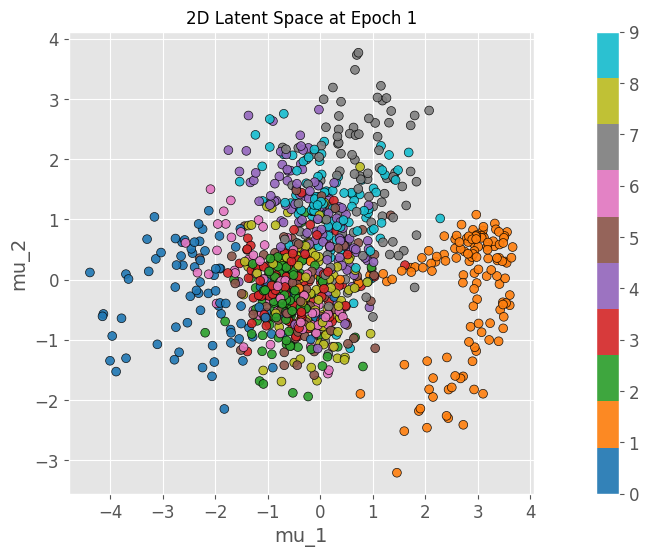

Epoch 2/20, Loss: 165.3171
Mean:  tensor([1.6544, 2.7703])
Logvar:  tensor([-3.7961, -2.9487])
Z:  tensor([1.5860, 2.6965])
Eps:  tensor([-0.4563, -0.3223])


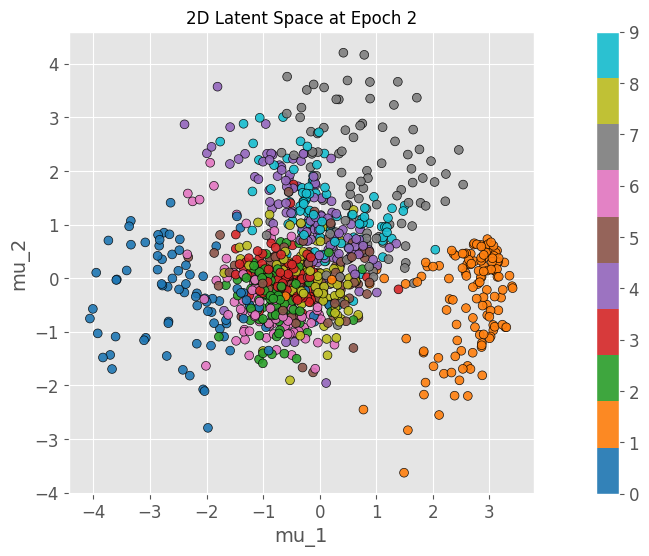

Epoch 3/20, Loss: 159.5190
Mean:  tensor([1.9616, 2.8186])
Logvar:  tensor([-4.4437, -3.8171])
Z:  tensor([2.1143, 2.6713])
Eps:  tensor([ 1.4086, -0.9929])


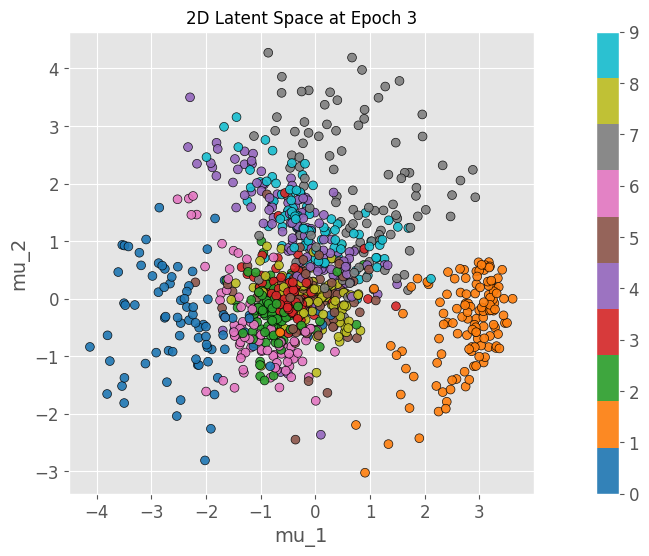

Epoch 4/20, Loss: 155.5852
Mean:  tensor([1.7951, 2.6682])
Logvar:  tensor([-4.3599, -3.6033])
Z:  tensor([1.9087, 2.4244])
Eps:  tensor([ 1.0051, -1.4777])


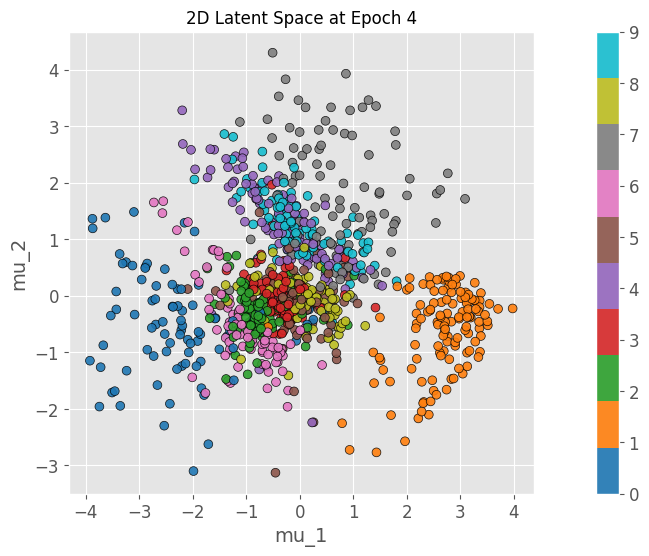

Epoch 5/20, Loss: 152.9929
Mean:  tensor([1.7758, 2.4710])
Logvar:  tensor([-4.0722, -3.5890])
Z:  tensor([1.5507, 2.5116])
Eps:  tensor([-1.7241,  0.2444])


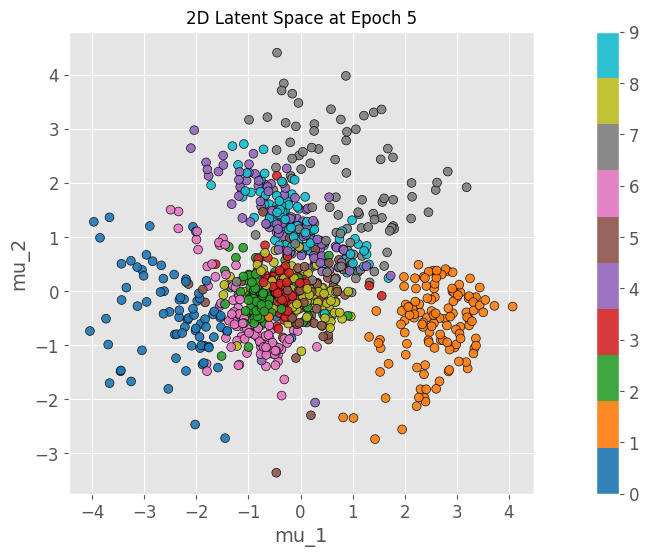

Epoch 6/20, Loss: 150.9819
Mean:  tensor([1.8026, 2.5881])
Logvar:  tensor([-4.6129, -4.0767])
Z:  tensor([1.6850, 2.5177])
Eps:  tensor([-1.1806, -0.5402])


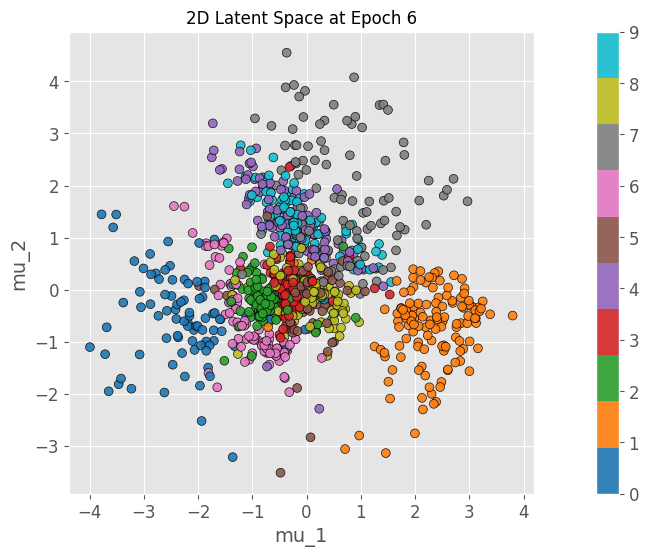

Epoch 7/20, Loss: 149.2094
Mean:  tensor([1.4590, 2.2027])
Logvar:  tensor([-4.5729, -3.8634])
Z:  tensor([1.3564, 2.1919])
Eps:  tensor([-1.0094, -0.0741])


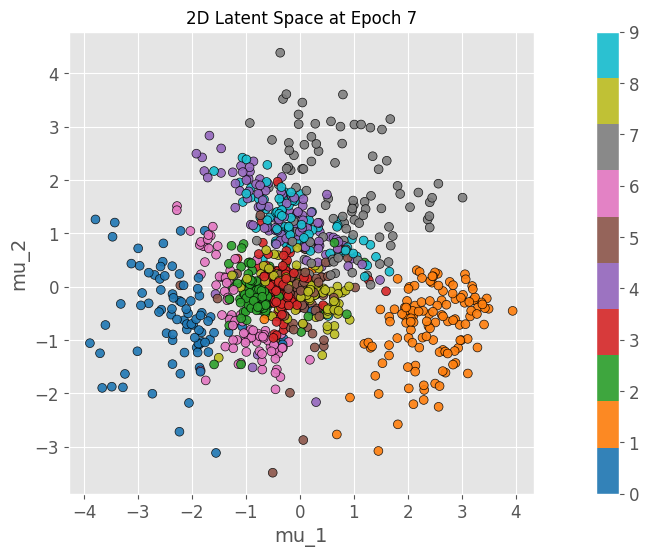

Epoch 8/20, Loss: 147.7006
Mean:  tensor([1.5351, 2.2710])
Logvar:  tensor([-4.7359, -4.1104])
Z:  tensor([1.6682, 2.4546])
Eps:  tensor([1.4204, 1.4337])


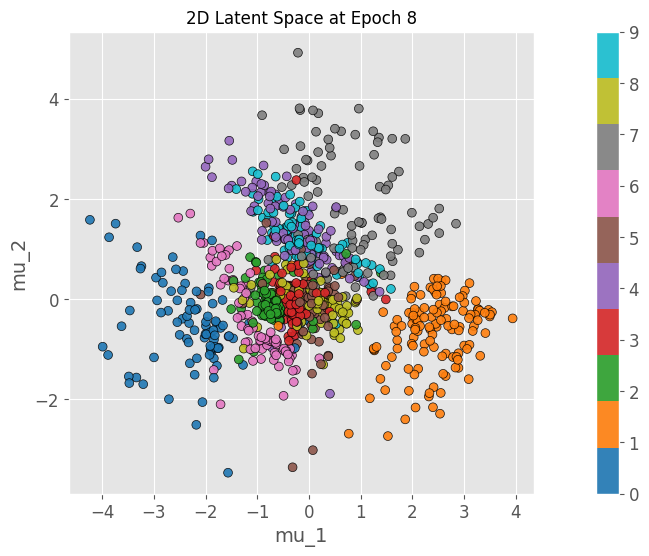

Epoch 9/20, Loss: 146.8129
Mean:  tensor([1.4723, 2.2795])
Logvar:  tensor([-4.5377, -4.0716])
Z:  tensor([1.5348, 2.2694])
Eps:  tensor([ 0.6049, -0.0776])


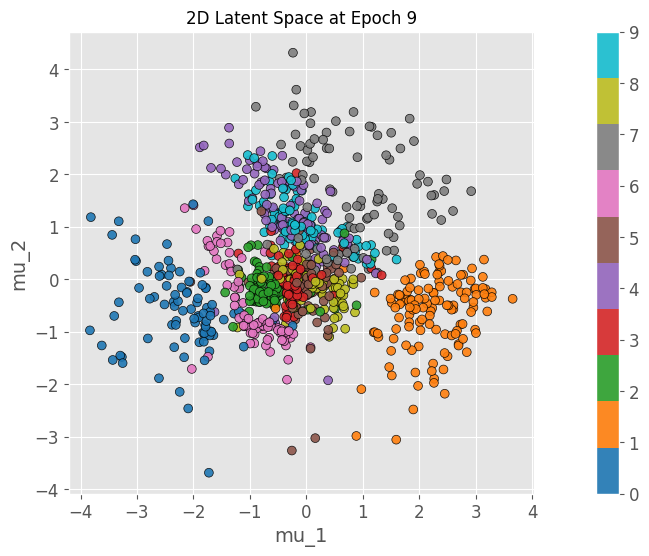

Epoch 10/20, Loss: 145.8356
Mean:  tensor([1.4695, 2.1577])
Logvar:  tensor([-4.5708, -4.2794])
Z:  tensor([1.2993, 1.9877])
Eps:  tensor([-1.6736, -1.4452])


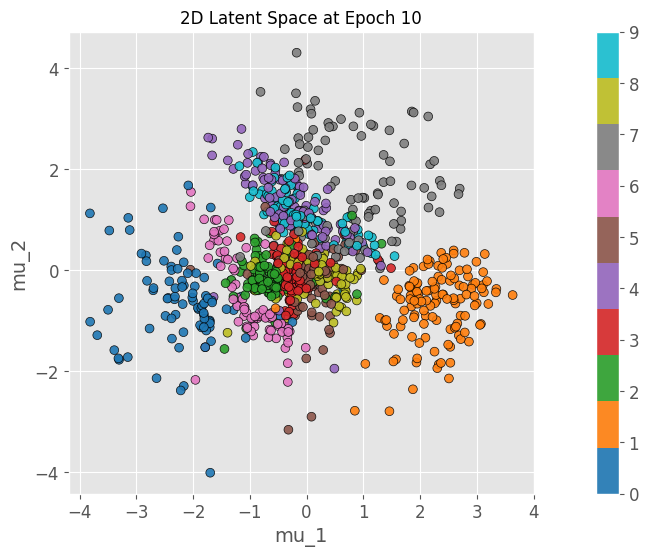

Epoch 11/20, Loss: 144.8700
Mean:  tensor([1.4566, 2.1863])
Logvar:  tensor([-4.7661, -4.3634])
Z:  tensor([1.4055, 2.2077])
Eps:  tensor([-0.5533,  0.1901])


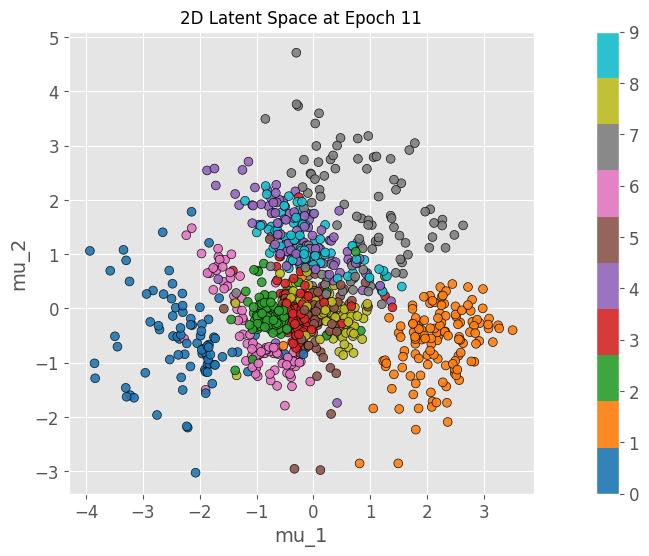

Epoch 12/20, Loss: 144.2565
Mean:  tensor([1.4751, 2.1701])
Logvar:  tensor([-4.7218, -4.5124])
Z:  tensor([1.2453, 2.0301])
Eps:  tensor([-2.4359, -1.3368])


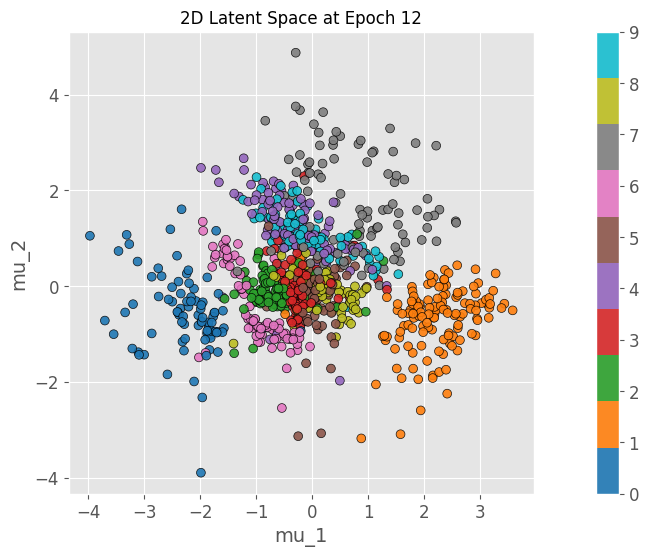

Epoch 13/20, Loss: 143.7042
Mean:  tensor([1.3338, 2.0101])
Logvar:  tensor([-4.9079, -4.5731])
Z:  tensor([1.2843, 1.8404])
Eps:  tensor([-0.5755, -1.6701])


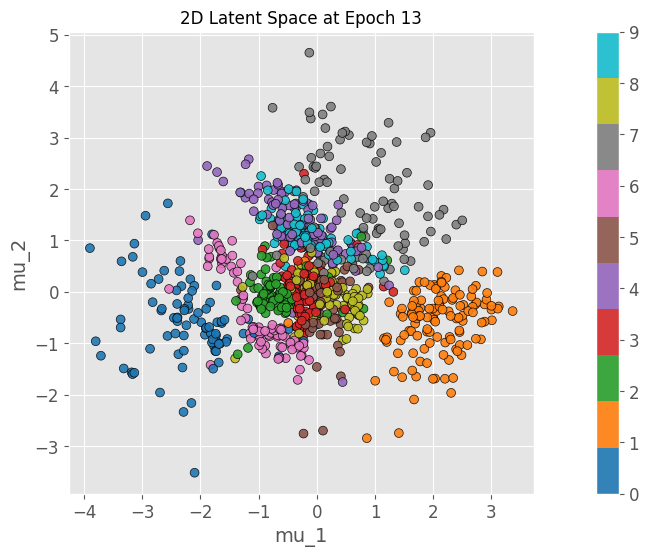

Epoch 14/20, Loss: 143.2922
Mean:  tensor([1.4310, 2.1424])
Logvar:  tensor([-4.6730, -4.2443])
Z:  tensor([1.5129, 2.0123])
Eps:  tensor([ 0.8476, -1.0862])


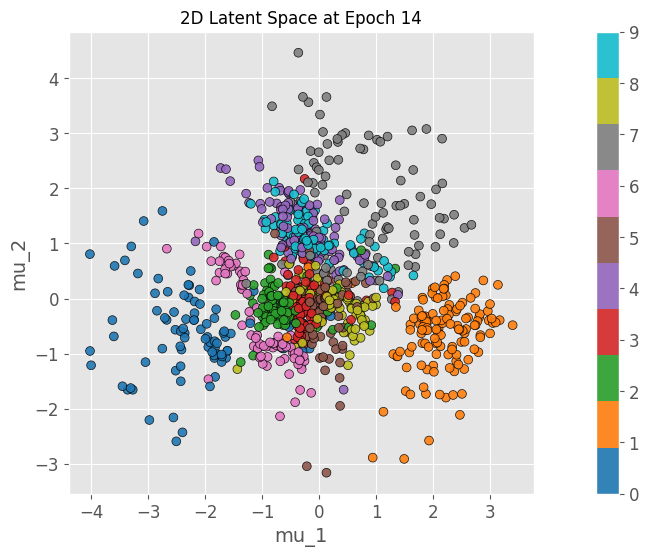

Epoch 15/20, Loss: 142.6698
Mean:  tensor([1.4918, 2.0826])
Logvar:  tensor([-4.5777, -4.3544])
Z:  tensor([1.6305, 2.2005])
Eps:  tensor([1.3683, 1.0398])


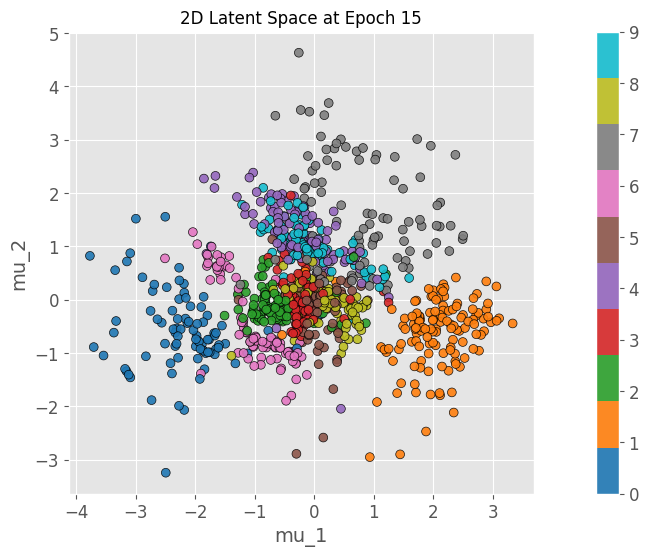

Epoch 16/20, Loss: 142.1015
Mean:  tensor([1.3988, 2.0562])
Logvar:  tensor([-4.7563, -4.3872])
Z:  tensor([1.1673, 2.2091])
Eps:  tensor([-2.4975,  1.3710])


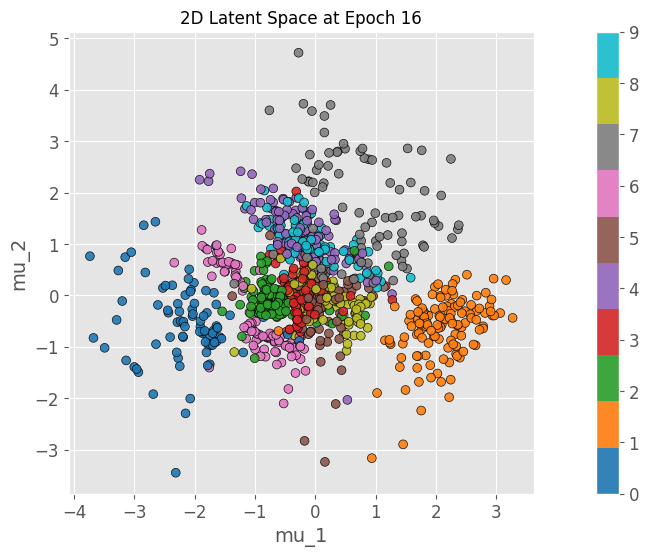

Epoch 17/20, Loss: 141.8977
Mean:  tensor([1.3563, 2.1860])
Logvar:  tensor([-4.6846, -4.5100])
Z:  tensor([1.3885, 2.2847])
Eps:  tensor([0.3349, 0.9411])


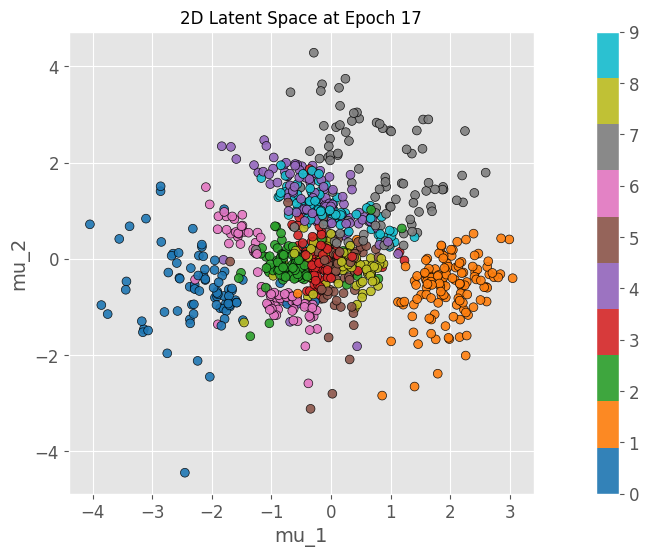

Epoch 18/20, Loss: 141.4211
Mean:  tensor([1.2868, 1.9591])
Logvar:  tensor([-4.5637, -4.4503])
Z:  tensor([1.4375, 2.0641])
Eps:  tensor([1.4756, 0.9718])


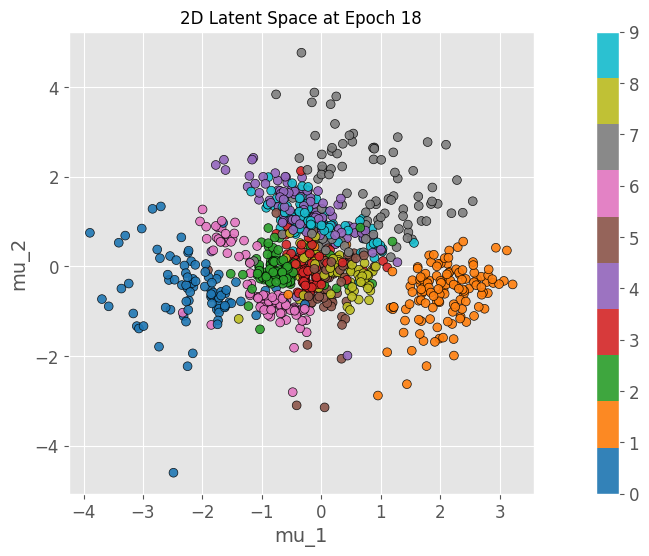

Epoch 19/20, Loss: 140.9579
Mean:  tensor([1.4390, 2.0797])
Logvar:  tensor([-4.3631, -4.2292])
Z:  tensor([1.2842, 1.8700])
Eps:  tensor([-1.3717, -1.7380])


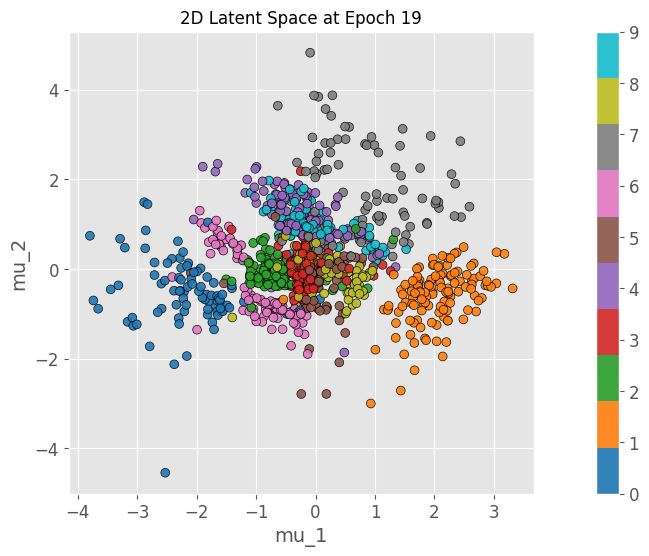

Epoch 20/20, Loss: 140.6555
Mean:  tensor([1.4011, 2.0406])
Logvar:  tensor([-4.5138, -4.2580])
Z:  tensor([1.2883, 2.0263])
Eps:  tensor([-1.0771, -0.1201])


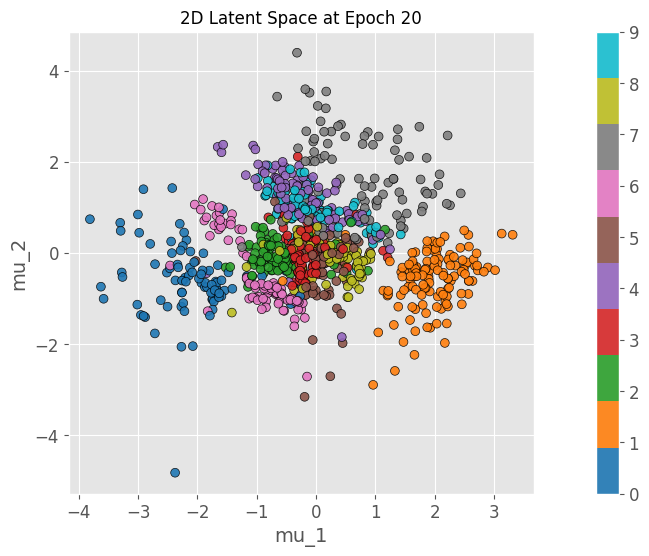

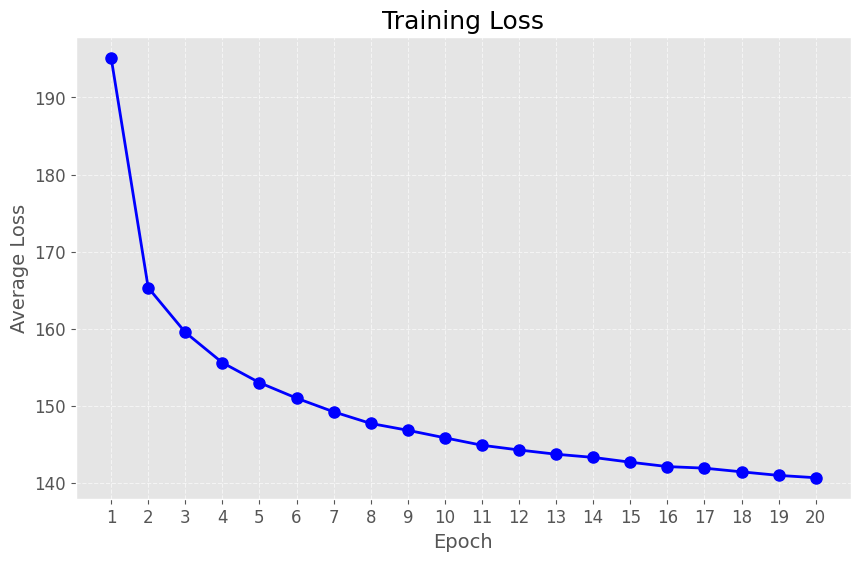

In [132]:
plt.style.use('ggplot')
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

num_epochs = 20
loss_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar, z, _ = model(data)
        loss = loss_function(data, x_recon, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    avg_loss = train_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    model.eval()
    all_mu = []
    all_labels = []
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            _, mu, logvar, z, eps = model(data)
            print("Mean: ", mu[0])
            print("Logvar: ", logvar[0])
            print("Z: ", z[0])
            print("Eps: ", eps[0])
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())
            break

    all_mu = np.concatenate(all_mu, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    plt.figure(figsize=(8,6))
    sc = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                     c=all_labels, cmap='tab10', s=40, alpha=0.9, edgecolors='k')
    plt.title(f"2D Latent Space at Epoch {epoch+1}", fontsize=12)
    plt.xlabel("mu_1", fontsize=14)
    plt.ylabel("mu_2", fontsize=14)
    cbar = plt.colorbar(sc, pad=0.1, ticks=range(10))
    cbar.ax.set_yticklabels([str(i) for i in range(10)])
    if epoch == num_epochs-1:
        plt.savefig(f"latent_space_epoch_{epoch+1}.png", dpi=300)
    plt.show()


plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), loss_history, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title("Training Loss", fontsize=18)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Average Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, num_epochs+1))
plt.show()

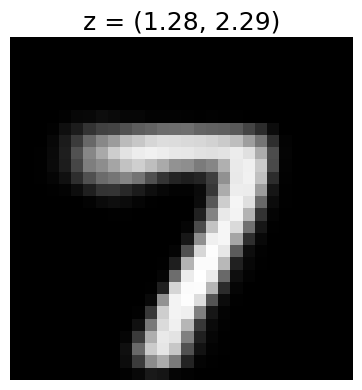

In [133]:
latent_dim = model.latent_dim

batch_size = 1
z_random = torch.tensor([1.2771, 2.2900]).to(device)

model.eval()
with torch.no_grad():
    generated = model.decoder(z_random)
    generated = generated.view(batch_size, 1, 28, 28)

plt.subplots(1, batch_size, figsize=(4, 4))
for i in range(batch_size):
    plt.imshow(generated[i].cpu().squeeze(), cmap='gray')
    plt.axis("off")
    z_values = z_random.detach().cpu().numpy()
    z_string = ", ".join([f"{val:.2f}" for val in z_values])
    plt.title(f"z = ({z_string})", fontsize=18)

plt.tight_layout()
plt.show()

DIFFUSION MODEL

In [134]:
import torch
import random
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

seed = 43
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda")


In [135]:
diffusion_steps = 10
beta_start = 0.01
beta_end = 0.1


In [136]:
def round_tensor(tensor):
    return torch.round(tensor, decimals=3)

def format_tensor(tensor):
    if isinstance(tensor, torch.Tensor):
        if tensor.ndim == 0 or tensor.numel() == 1:
            return f"{tensor.item():.3f}"
        else:
            return "[" + ", ".join(f"{v:.3f}" for v in tensor.tolist()) + "]"
    elif isinstance(tensor, (float, int)):
        return f"{tensor:.3f}"
    else:
        return str(tensor)


In [137]:
class DiffusionModel:
    def __init__(self, num_steps=diffusion_steps, beta_start=beta_start, beta_end=beta_end):
        self.num_steps = num_steps
        self.betas = torch.linspace(beta_start, beta_end, num_steps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - self.alphas_cumprod)
        self.one_val = torch.tensor(1.0)
        self.prng_generator = torch.Generator()

    def forward_diffusion(self, x0, t):
        # noise = round_tensor(torch.randn_like(x0))
        noise = round_tensor(torch.Tensor([-0.65, -0.71]))

        sqrt_alpha_cumprod_t = round_tensor(self.sqrt_alphas_cumprod[t].view(-1, 1))
        sqrt_one_minus_alpha_cumprod_t = round_tensor(self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1))
        noisy_x = round_tensor(sqrt_alpha_cumprod_t * x0 + sqrt_one_minus_alpha_cumprod_t * noise)

        print(f"{'x0:':<40}{format_tensor(x0)}")
        print(f"{'noise:':<40}{format_tensor(noise)}")
        print(f"{'sqrt_alphas_cumprod[t]:':<40}{format_tensor(sqrt_alpha_cumprod_t)}")
        print(f"{'sqrt_one_minus_alphas_cumprod[t]:':<40}{format_tensor(sqrt_one_minus_alpha_cumprod_t)}")
        print(f"{'noisy_x:':<40}{noisy_x}")

    def _get_previous_timestep(self, timestep):
        return timestep - 1 if timestep > 0 else -1

    def _calculate_variance(self, timestep):
        return self.betas[timestep]

    def reverse_diffusion(self, current_timestep, current_latents, noise_prediction):
        previous_timestep = self._get_previous_timestep(current_timestep)
        previous_timestep = (torch.tensor(previous_timestep)).long().item()

        cumprod_alpha_current = round_tensor(self.alphas_cumprod[current_timestep])
        cumprod_alpha_previous = round_tensor(self.alphas_cumprod[previous_timestep]) if previous_timestep >= 0 else self.one_val

        cumprod_beta_current = round_tensor(1 - cumprod_alpha_current)
        cumprod_beta_previous = round_tensor(1 - cumprod_alpha_previous)

        current_alpha_ratio = round_tensor(cumprod_alpha_current / cumprod_alpha_previous)
        current_beta_ratio = round_tensor(1 - current_alpha_ratio)

        predicted_x0 = round_tensor((current_latents - cumprod_beta_current.sqrt() * noise_prediction) / cumprod_alpha_current.sqrt())

        original_coefficient = round_tensor((cumprod_alpha_previous.sqrt() * current_beta_ratio) / cumprod_beta_current)
        latent_coefficient = round_tensor(current_alpha_ratio.sqrt() * cumprod_beta_previous / cumprod_beta_current)

        prior_mean_prediction = round_tensor(original_coefficient * predicted_x0 + latent_coefficient * current_latents)

        variance_term = 0
        if current_timestep > 0:
            target_device = noise_prediction.device
            # noise_component = torch.randn(
            #     noise_prediction.shape,
            #     generator=self.prng_generator,
            #     device=target_device,
            #     dtype=noise_prediction.dtype
            # )
            noise_component = round_tensor(torch.Tensor([-0.65, -0.71]))
            variance_term = round_tensor(self._calculate_variance(current_timestep).sqrt() * noise_component)

        prior_sample_prediction = round_tensor(prior_mean_prediction + variance_term)

        print(f"{'current_timestep:':<40}{(current_timestep)}")
        print(f"{'previous_timestep:':<40}{(previous_timestep)}")
        print(f"{'cumprod_alpha_current:':<40}{format_tensor(cumprod_alpha_current)}")
        print(f"{'cumprod_alpha_previous:':<40}{format_tensor(cumprod_alpha_previous)}")
        print(f"{'cumprod_beta_current:':<40}{format_tensor(cumprod_beta_current)}")
        print(f"{'cumprod_beta_previous:':<40}{format_tensor(cumprod_beta_previous)}")
        print(f"{'current_alpha_ratio:':<40}{format_tensor(current_alpha_ratio)}")
        print(f"{'current_beta_ratio:':<40}{format_tensor(current_beta_ratio)}")
        print(f"{'predicted_x0:':<40}{format_tensor(predicted_x0)}")
        print(f"{'original_coefficient:':<40}{format_tensor(original_coefficient)}")
        print(f"{'latent_coefficient:':<40}{format_tensor(latent_coefficient)}")
        print(f"{'--> prior_mean_prediction:':<40}{format_tensor(prior_mean_prediction)}")
        print(f"{'variance_term:':<40}{format_tensor(variance_term)}")
        print(f"{'prior_sample_prediction:':<40}{format_tensor(prior_sample_prediction)}")

noise_scheduler = DiffusionModel()


In [138]:
x_0 = torch.Tensor([0.300, 0.400])
noise_scheduler.forward_diffusion(x_0, 7)

x0:                                     [0.300, 0.400]
noise:                                  [-0.650, -0.710]
sqrt_alphas_cumprod[t]:                 0.831
sqrt_one_minus_alphas_cumprod[t]:       0.557
noisy_x:                                tensor([[-0.1130, -0.0630]])


In [ ]:
noise_scheduler.reverse_diffusion(current_timestep=7,
                                  current_latents=torch.Tensor([-0.15, -0.20]),
                                  noise_prediction=torch.Tensor([0.30, 0.40]))


current_timestep:                       7
previous_timestep:                      6
cumprod_alpha_current:                  0.690
cumprod_alpha_previous:                 0.750
cumprod_beta_current:                   0.310
cumprod_beta_previous:                  0.250
current_alpha_ratio:                    0.920
current_beta_ratio:                     0.080
predicted_x0:                           [-0.382, -0.509]
original_coefficient:                   0.223
latent_coefficient:                     0.774
--> prior_mean_prediction:              [-0.201, -0.268]
variance_term:                          [-0.184, -0.201]
prior_sample_prediction:                [-0.385, -0.469]


FLOW MATCHING

In [148]:
import torch
import torch.nn as nn

class Flow(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.linear = nn.Linear(2, 1)

        with torch.no_grad():
            self.linear.weight.copy_(torch.tensor([[0.3, 0.8]]))
            self.linear.bias.copy_(torch.tensor([0]))

            self.linear.weight.requires_grad = False
            self.linear.bias.requires_grad = False

    def forward(self,  t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        t = t.unsqueeze(0).float()
        x = torch.cat([x, t], dim=0)
        x = self.linear(x)
        x = nn.Tanh()(x)
        return x

In [149]:
# Khởi tạo model - loss
model = Flow()
loss_fn = nn.MSELoss()

# Giá trị cho trước
x_1 = torch.tensor([0.6])
x_0 = torch.tensor([-0.2])
t = torch.tensor(0.6)
###

# Tính toán
x_t = (1 - t) * x_0 + t*x_1
print("x_t:", x_t.item())

pred = model(t, x_t)
print("\npred:", pred.item())

target = x_1 - x_0
print("\ntarget:", target.item())

# Tính toán loss
loss = loss_fn(pred, target)
print("\n\n\n***Đáp án***\nloss:  ", loss.item())

x_t: 0.2800000309944153

pred: 0.5109392404556274

target: 0.800000011920929



***Đáp án***
loss:   0.08355613052845001


In [150]:
class Flow2(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.linear = nn.Linear(2, 1)

        with torch.no_grad():
            self.linear.weight.copy_(torch.tensor([[0.7, 0.9]]))
            self.linear.bias.copy_(torch.tensor([0]))

            self.linear.weight.requires_grad = False
            self.linear.bias.requires_grad = False

    def forward(self,  t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        t = t.unsqueeze(0).float()
        x = torch.cat([x, t], dim=0)
        x = self.linear(x)
        x = nn.Tanh()(x)
        return x

In [151]:
# Khởi tạo model
model = Flow2()

# Các giá trị cho trước
x1 = torch.tensor([0.7])
steps = 10
###

delta = 1/steps
t1 = torch.tensor(0) + delta
print("t1:", t1)

# Tính toán x2
x2 = x1 + delta * model(t1, x1)
print("x2:", x2.item())
t2 = t1 + delta
print("t2:", t2)

# Tính toán x3
x3 = x2 + delta * model(t2, x2)
print("\n\n\n***Đáp án***\nx3:  ", x3.item())


t1: tensor(0.1000)
x2: 0.752266526222229
t2: tensor(0.2000)



***Đáp án***
x3:   0.8131197094917297
